In [1]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint


from network import NetCNN1D, NetCNN2D_CSP


from mne.decoding import CSP
from sklearn.model_selection import StratifiedKFold,  StratifiedShuffleSplit

import numpy as np
import sys, os

import dataset_NewEEG
from config_NewEEG import Config

import matplotlib.pyplot as plt


import pandas as pd
import pickle
import tqdm



config = Config()



# Choose from: 'CLeft', 'CRight', 'CUp' and 'CDown'
config.used_classes = [['CLeft'], ['CRight']]
config.session_type = 'S2'


config.test_session = 9


config.t_start = 0 
config.t_end = 3.0

config.window_size = 2.0
config.stride = 0.5



config.n_csp_components = 3

# All available channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']
config.used_channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']


model = NetCNN2D_CSP(len(config.used_classes))
model.build((32, 3, 750, 1))
model.summary()

model = NetCNN1D(len(config.used_classes))
model.build((32, 750, 3))
model.summary()





Model: "net_cnn2d_csp"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 3, 108, 16)          608       
                                                                 
 sequential_1 (Sequential)   (32, 3, 22, 32)           10912     
                                                                 
 sequential_2 (Sequential)   (32, 32)                  0         
                                                                 
 fc (Sequential)             (32, 2)                   4482      
                                                                 
Total params: 16002 (62.51 KB)
Trainable params: 15906 (62.13 KB)
Non-trainable params: 96 (384.00 Byte)
_________________________________________________________________
Model: "net_cnn1d"
_________________________________________________________________
 Layer (type)                Output Shape              Pa

In [ ]:
X, y = [], []
for i in range(1, 12):
    if i == config.test_session:
        continue
    
    Xi, yi = dataset_NewEEG.session_dataset(config, f'I{i:02d}')
    X.append(Xi)
    y.append(yi)


X, y = np.concatenate(X), np.concatenate(y)

print(X.shape)
print(y.shape)

(322, 13, 750)
(322,)


0it [00:00, ?it/s]

Training indices:  [209  19 188  37  11 314  17 238  44 175 267 113 116 300  38 163 303 281
 115  70   8  69 132 250 298 216  27 131 215  43  42  78 204  74 265  86
 148 165  20 184  40  95  64  45 180 203  52 227 125  12 237 318 155 242
 285 105 112 213  56 159 279  66 287 222   4  54 194 168  51 229 152 191
 253  49 126 244   5 172  25 308 218 266 211  60  65  94  34 190  99 100
  26 289  89 193 320 284 177  24  16 138 221 143 106  85 319   6 271 196
 147 198 225 135 309 139  22 290 114 219 260  39 192 178  57 111 103  53
 179 256 123 110 282   3  93 292 202 273 262 117 119 295 224 288 104 153
 274 182  90  46  47 201  32 252 241 316 293  91 199 255  13  67 263  36
  31 197 239 302 171 230  80  72 269 297 294 254 220 130 277   1 264 170
 149 107  28 299 189  29 185 173 257 286 259 164 311 127   0  14 275 137
 231 210 228  61 270  88 205 133 157 108 235  87 214 146 240  71 121  35
 187  33  98  10  63 272 109 195 249 283  81 212  92 145 128 167  15 306
 246 268 247 243  50 169 312 102

INFO:tensorflow:Assets written to: best_model2D_fold_0.tf\assets


INFO:tensorflow:Assets written to: best_model2D_fold_0.tf\assets


INFO:tensorflow:Assets written to: best_model2D_fold_0.tf\assets


...

INFO:tensorflow:Assets written to: best_model2D_fold_2.tf\assets


INFO:tensorflow:Assets written to: best_model2D_fold_2.tf\assets
3it [18:06, 362.13s/it]


INFO:tensorflow:Assets written to: best_model2D.tf\assets


INFO:tensorflow:Assets written to: best_model2D.tf\assets


Best model saved (Fold 1) with validation accuracy: 0.6259



61.68% +- 0.6


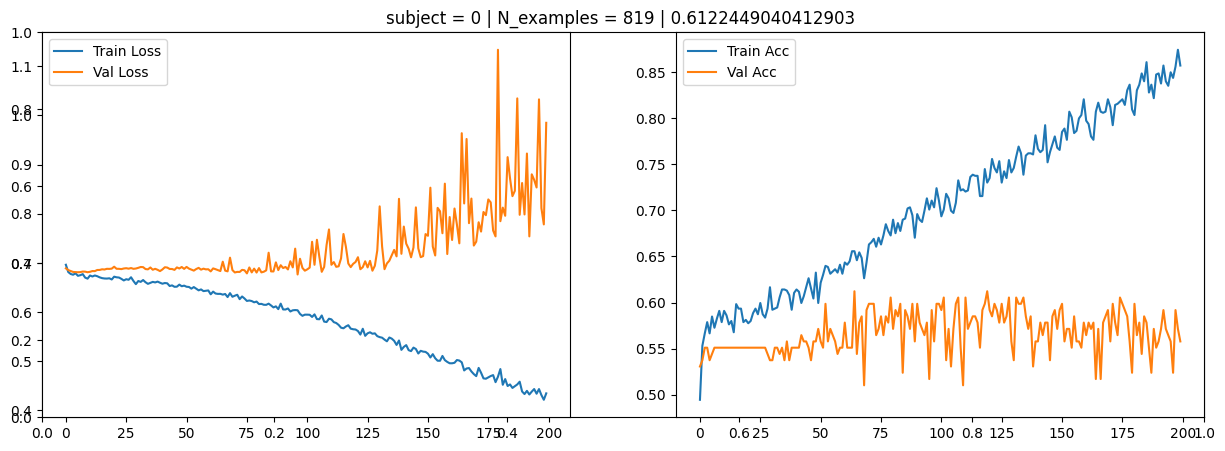

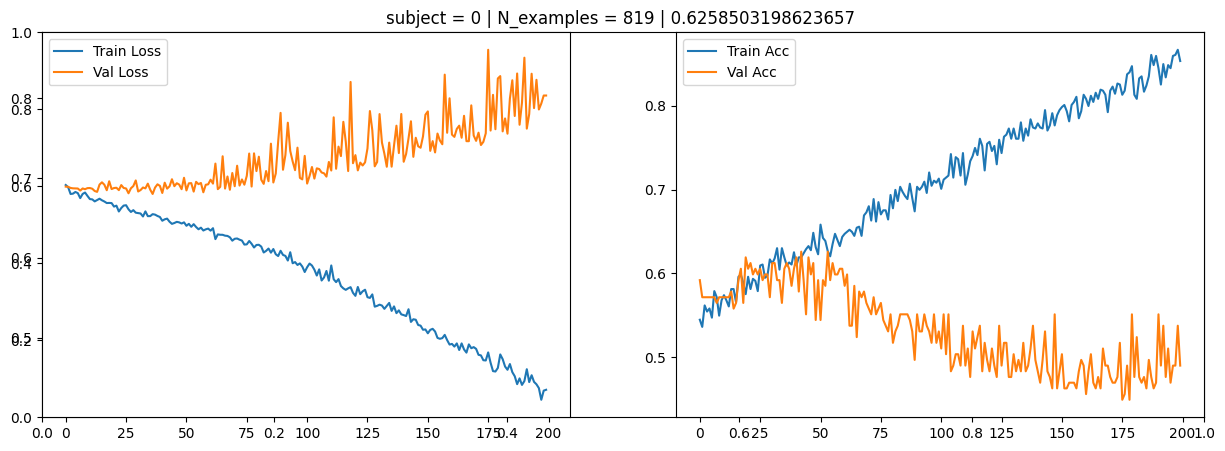

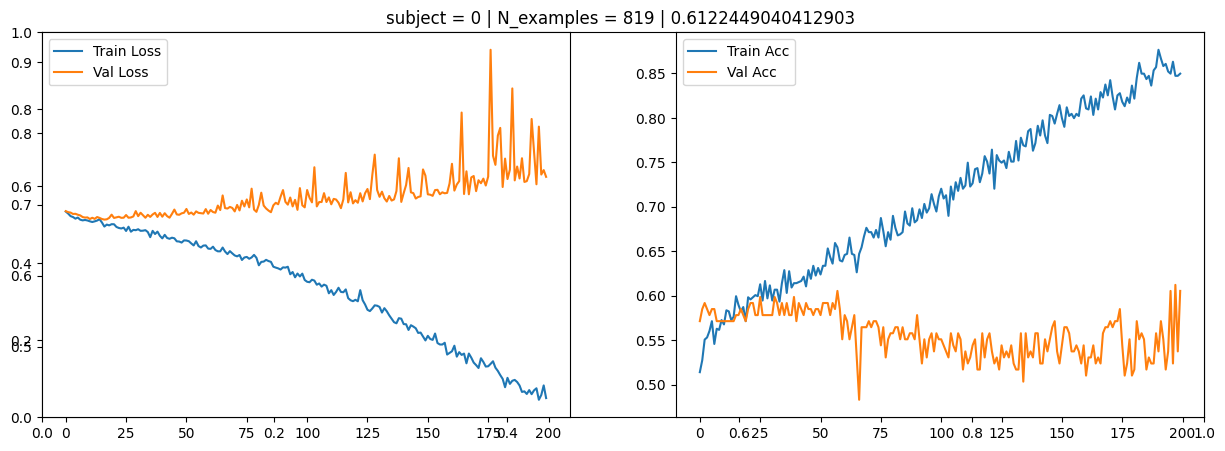

In [ ]:
#crossValidation_KF = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
crossValidation_KF = StratifiedShuffleSplit(n_splits=3, test_size=0.15, random_state=0)

                    

acc = []
Y_preds = []

shuffle_indices = np.random.permutation(len(y))



X = X[shuffle_indices]
y = y[shuffle_indices]


best_model = None
best_acc = 0
best_fold_idx = 0
best_csp = None





for fold_idx, (train_index, valid_index) in tqdm.tqdm(enumerate(crossValidation_KF.split(X,y))):


    X_train = X[train_index]
    Y_train = y[train_index]
    X_valid = X[valid_index]
    Y_valid = y[valid_index]
    print("Training indices: ", train_index)
    print("Validation indices: ", valid_index)


    # A better alternative is to slice the dataset before for preocessing time efficiency, however since our dataset is extremely small it doesn't matter in this case.
    X_train, Y_train = dataset_NewEEG.slice_EEG_epoch(config, X_train, Y_train)
    X_valid, Y_valid = dataset_NewEEG.slice_EEG_epoch(config, X_valid, Y_valid)


    #mu = X_train.mean()
    #sig = X_train.std()

    #X_train = (X_train - mu)/sig
    #X_valid = (X_valid - mu)/sig



    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')



    csp = CSP(n_components=config.n_csp_components, reg=None, log=None, norm_trace=False, transform_into='csp_space')

    X_train = csp.fit_transform(X_train, Y_train)
    X_valid = csp.transform(X_valid)

    sys.stdout.close()
    sys.stdout = old_stdout

    #print(X_train.shape)
    X_train = np.expand_dims(X_train, 3)
    X_valid = np.expand_dims(X_valid, 3)

    #X_train = X_train.transpose(0, 2, 1)
    #X_valid = X_valid.transpose(0, 2, 1)

    Y_train = tf.keras.utils.to_categorical(Y_train, num_classes = len(config.used_classes))
    Y_valid = tf.keras.utils.to_categorical(Y_valid, num_classes = len(config.used_classes))



    model = NetCNN2D_CSP(len(config.used_classes)) #NetCNN2D_CSP(len(config.used_classes)) 


    model.compile(
            loss= CategoricalCrossentropy(from_logits=True, label_smoothing=0.05),
            optimizer=keras.optimizers.Adam(learning_rate=1e-4, weight_decay = 1e-5), 
            metrics=[keras.metrics.CategoricalAccuracy(name='acc')]
    ) 



    checkpoint_cb = ModelCheckpoint(f'best_model2D_fold_{fold_idx}.tf', save_best_only=True, monitor='loss', mode='min', verbose=0, save_format='tf')

    history = model.fit(X_train, Y_train, validation_data=(X_valid, Y_valid), epochs=200, batch_size=32, verbose=0, callbacks=[checkpoint_cb])

    
    val_acc = max(history.history['val_acc'])
    acc.append(val_acc)

    if val_acc > best_acc:
        best_acc = val_acc
        best_model = model
        best_fold_idx = fold_idx
        best_csp = csp 



    plt.figure(figsize=(15,5))
    plt.title(f"subject = {0} | N_examples = {X_train.shape[0]} | {max(history.history['val_acc'])} ")

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.legend(["Train Loss", "Val Loss"])

    plt.subplot(1,2,2)
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
    plt.legend(["Train Acc", "Val Acc"])

    acc.append(max(history.history['val_acc']))
    

if best_model is not None:
    best_model.save('best_model2D.tf', save_format='tf')
    print(f"Best model saved (Fold {best_fold_idx}) with validation accuracy: {best_acc:.4f}")

    with open('csp2D.pkl', 'wb') as f:
        pickle.dump(best_csp, f)


print("\n\n ================================== \n")
print(f"{100*np.mean(acc):.2f}% +- {100*np.std(acc):.1f}")

In [4]:
config.stride = 0.2
config.window_size = 2.0




model = tf.keras.models.load_model('best_model2D.tf')
model.trainable = False

with open('csp2D.pkl', 'rb') as f:
    csp_trained = pickle.load(f)


X, y = dataset_NewEEG.session_dataset(config, f'I{config.test_session:02d}')
X, y = dataset_NewEEG.slice_EEG_epoch(config, X, y)


X_csp_trained = csp_trained.transform(X)
X_csp_trained = np.expand_dims(X_csp_trained, 3)

y = tf.keras.utils.to_categorical(y, num_classes = len(config.used_classes))

print(model.evaluate(X_csp_trained, y)[1])







old_stdout = sys.stdout
sys.stdout = open(os.devnull, 'w')

X, y = dataset_NewEEG.session_dataset(config, f'I{config.test_session:02d}')
X, y = dataset_NewEEG.slice_EEG_epoch(config, X, y)

csp = CSP(n_components=config.n_csp_components, reg=None, log=None, norm_trace=False, transform_into='csp_space')
X = csp.fit_transform(X, y)
X = np.expand_dims(X, 3)

y = tf.keras.utils.to_categorical(y, num_classes = len(config.used_classes))


sys.stdout.close()
sys.stdout = old_stdout

print(model.evaluate(X, y)[1])

5/5 [==============================] - 1s 10ms/step - loss: 0.7193 - acc: 0.5267
0.5266666412353516
5/5 [==============================] - 0s 7ms/step - loss: 1.0440 - acc: 0.5267
0.5266666412353516


1it [00:27, 27.42s/it]

0.46666666865348816


2it [00:52, 26.26s/it]

0.5


3it [01:19, 26.37s/it]

0.6000000238418579


4it [01:46, 26.71s/it]

0.6000000238418579


5it [02:13, 26.63s/it]

0.699999988079071



57.33% +- 8.3


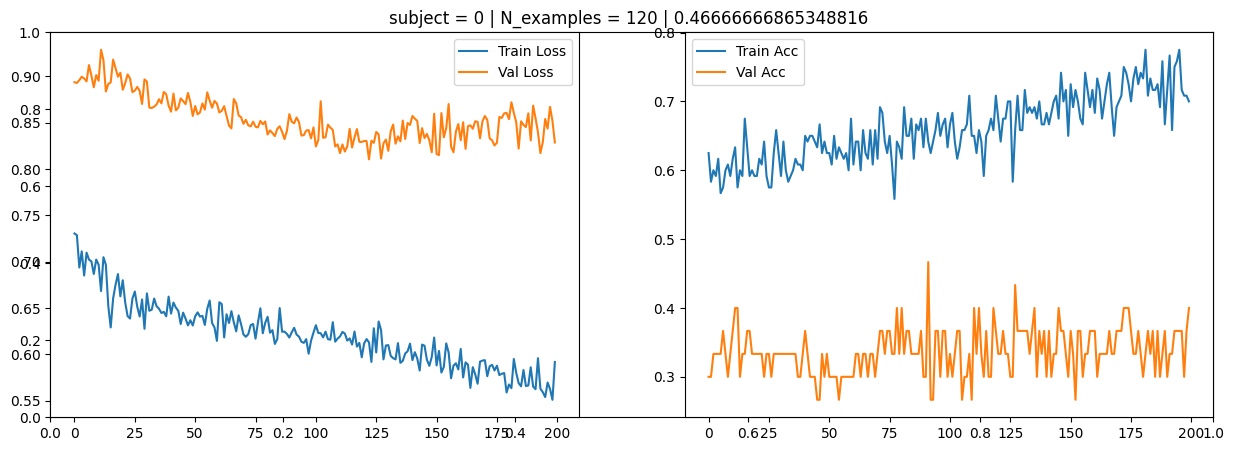

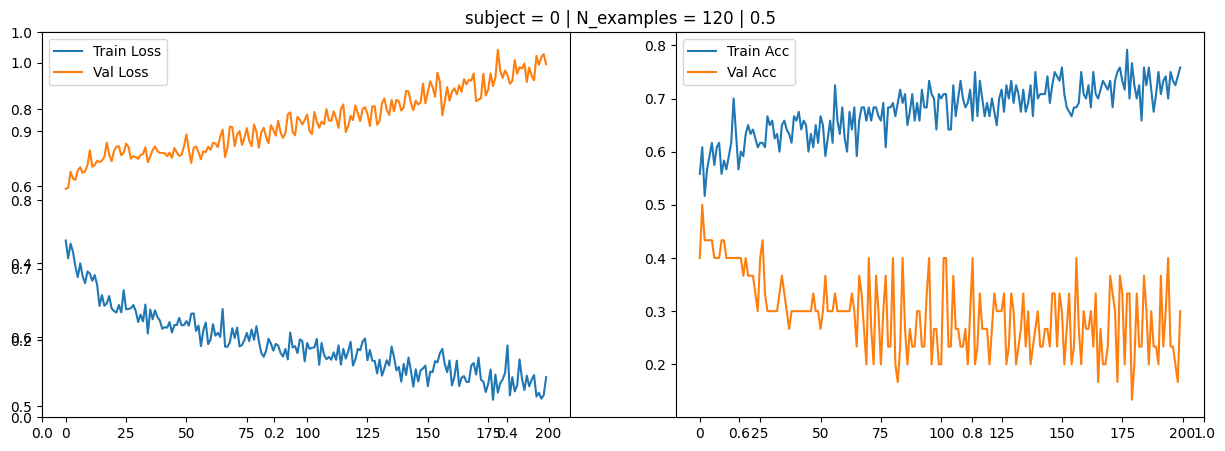

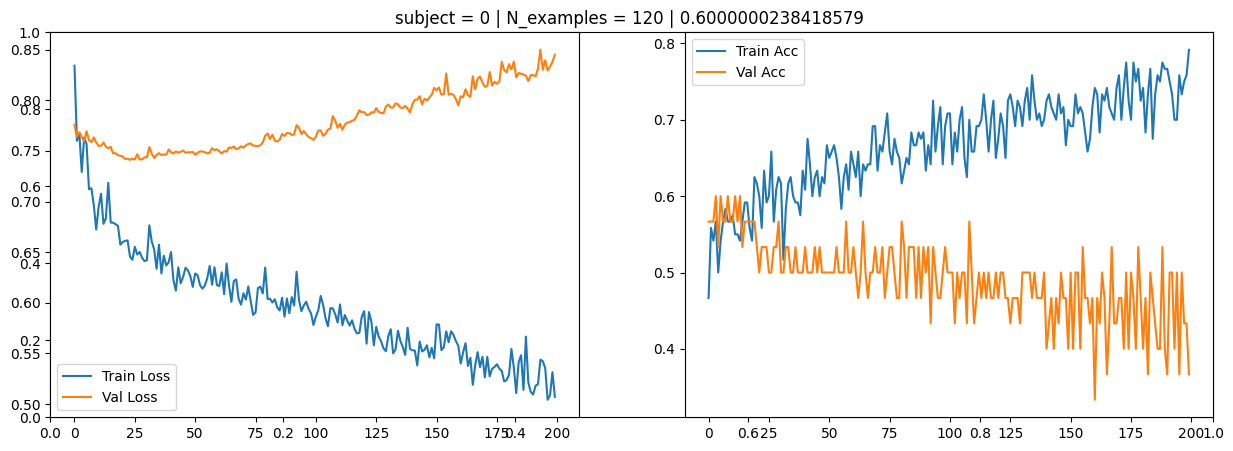

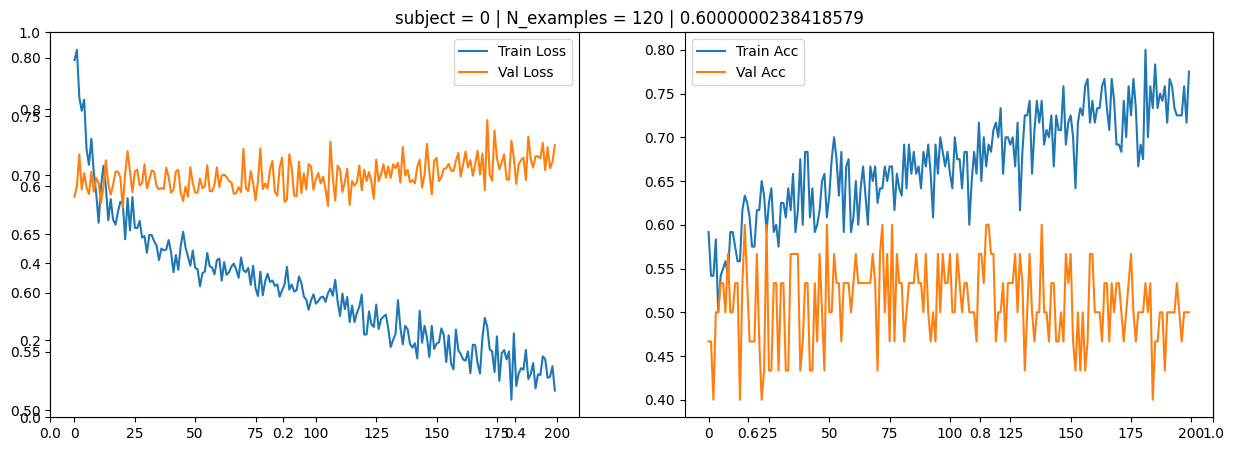

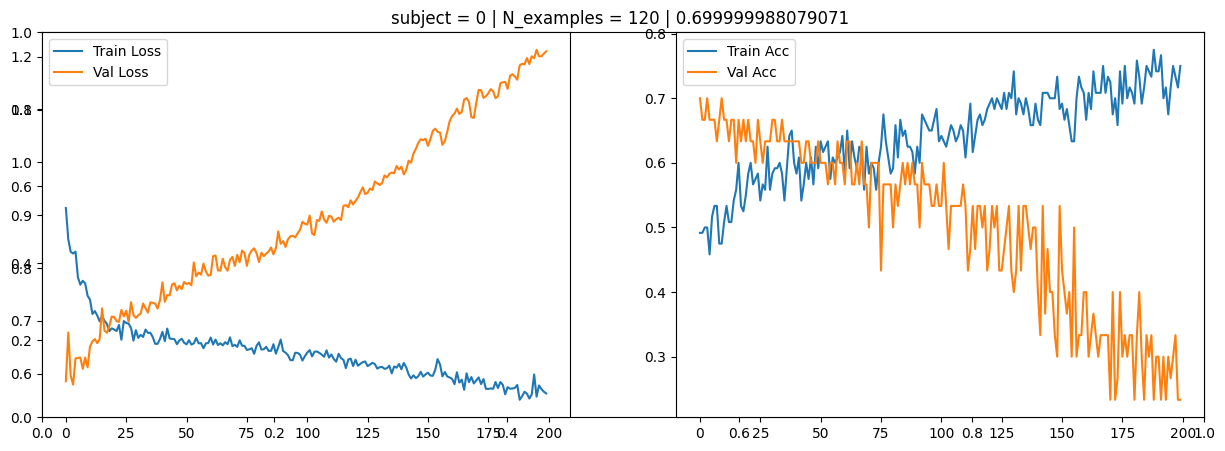

In [5]:
config.stride = 0.2
config.window_size = 2.0


X, y = dataset_NewEEG.session_dataset(config, f'I{config.test_session:02d}')










#crossValidation_KF = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
crossValidation_KF = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=0)


acc = []
Y_preds = []

shuffle_indices = np.random.permutation(len(y))



X = X[shuffle_indices]
y = y[shuffle_indices]

for train_index, valid_index in tqdm.tqdm(crossValidation_KF.split(X,y)):


    model = tf.keras.models.load_model('best_model2D.tf')
    #model.trainable = False 

    with open('csp2D.pkl', 'rb') as f:
        csp_trained = pickle.load(f)

    for layer in model.layers:
        layer.trainable = False

        if layer.name == 'fc':
            layer.trainable = True


    X_train = X[train_index]
    Y_train = y[train_index]
    X_valid = X[valid_index]
    Y_valid = y[valid_index]
    #print("Training indices: ", train_index)
    #print("Validation indices: ", valid_index)


    # A better alternative is to slice the dataset before for preocessing time efficiency, however since our dataset is extremely small it doesn't matter in this case.
    X_train, Y_train = dataset_NewEEG.slice_EEG_epoch(config, X_train, Y_train)
    X_valid, Y_valid = dataset_NewEEG.slice_EEG_epoch(config, X_valid, Y_valid)


    #mu = X_train.mean()
    #sig = X_train.std()

    #X_train = (X_train - mu)/sig
    #X_valid = (X_valid - mu)/sig



    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')



    #csp = CSP(n_components=config.n_csp_components, reg=None, log=None, norm_trace=False, transform_into='csp_space')

    X_train = csp_trained.transform(X_train)
    #X_train = csp.fit_transform(X_train, Y_train)
    X_valid = csp_trained.transform(X_valid)

    sys.stdout.close()
    sys.stdout = old_stdout

    #print(X_train.shape)
    X_train = np.expand_dims(X_train, 3)
    X_valid = np.expand_dims(X_valid, 3)

    #X_train = X_train.transpose(0, 2, 1)
    #X_valid = X_valid.transpose(0, 2, 1)

    Y_train = tf.keras.utils.to_categorical(Y_train, num_classes = len(config.used_classes))
    Y_valid = tf.keras.utils.to_categorical(Y_valid, num_classes = len(config.used_classes))



    #model = NetCNN2D_CSP(len(config.used_classes)) #NetCNN2D_CSP(len(config.used_classes)) 


    model.compile(
            loss= CategoricalCrossentropy(from_logits=True, label_smoothing=0.01),
            optimizer=keras.optimizers.Adam(learning_rate=1e-3, weight_decay = 5e-7), 
            metrics=[keras.metrics.CategoricalAccuracy(name='acc')]
    ) 



    

    history = model.fit(X_train, Y_train, validation_data=(X_valid, Y_valid), epochs=200, batch_size=16, verbose=0)

    
    plt.figure(figsize=(15,5))
    plt.title(f"subject = {0} | N_examples = {X_train.shape[0]} | {max(history.history['val_acc'])} ")

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.legend(["Train Loss", "Val Loss"])

    plt.subplot(1,2,2)
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
    plt.legend(["Train Acc", "Val Acc"])

    acc.append(max(history.history['val_acc']))
    print(acc[-1])
    

print("\n\n ================================== \n")
print(f"{100*np.mean(acc):.2f}% +- {100*np.std(acc):.1f}")




1it [00:26, 26.36s/it]

0.46666666865348816


2it [00:53, 26.79s/it]

0.46666666865348816


3it [01:19, 26.30s/it]

0.6000000238418579


4it [01:45, 26.20s/it]

0.699999988079071


5it [02:11, 26.26s/it]


0.6333333253860474



57.33% +- 9.3


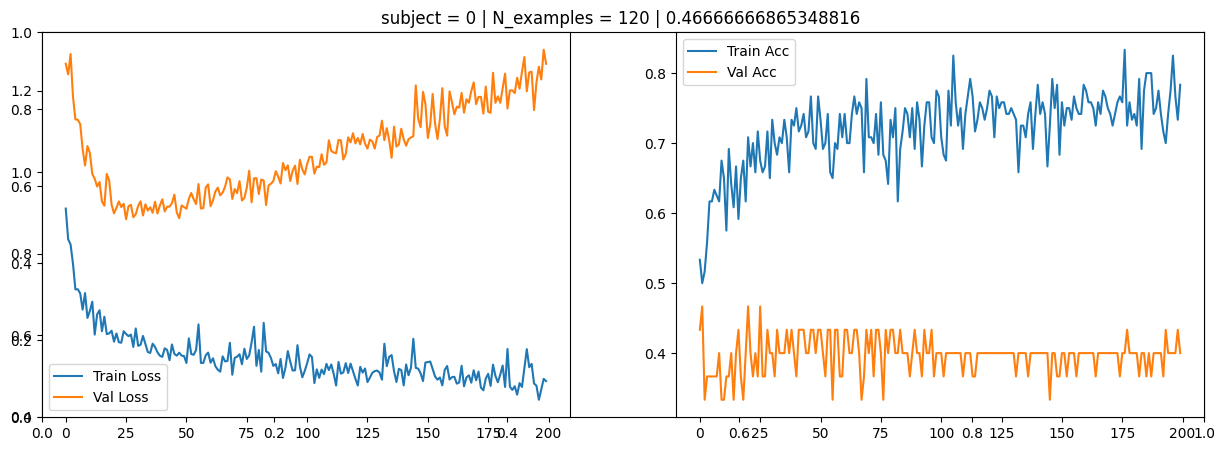

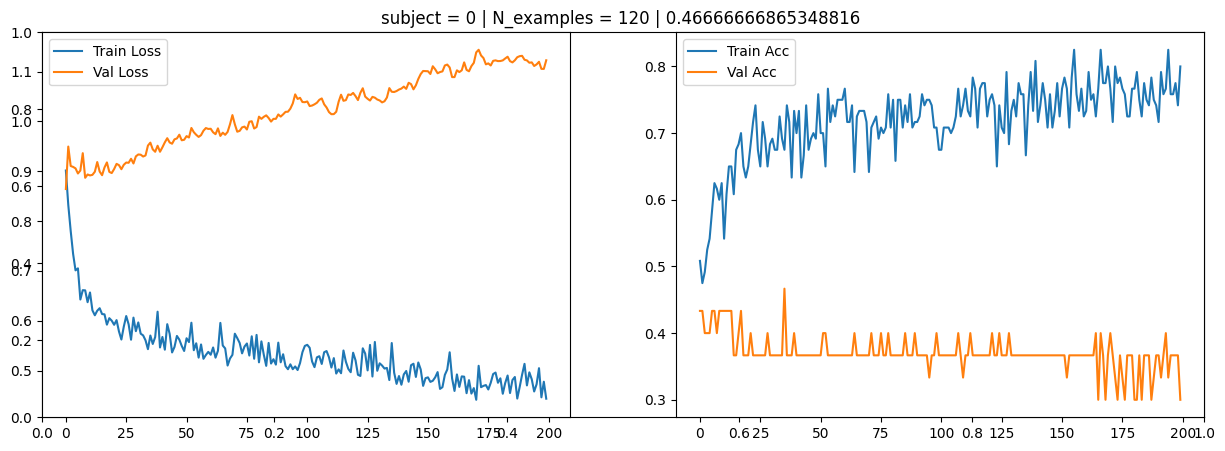

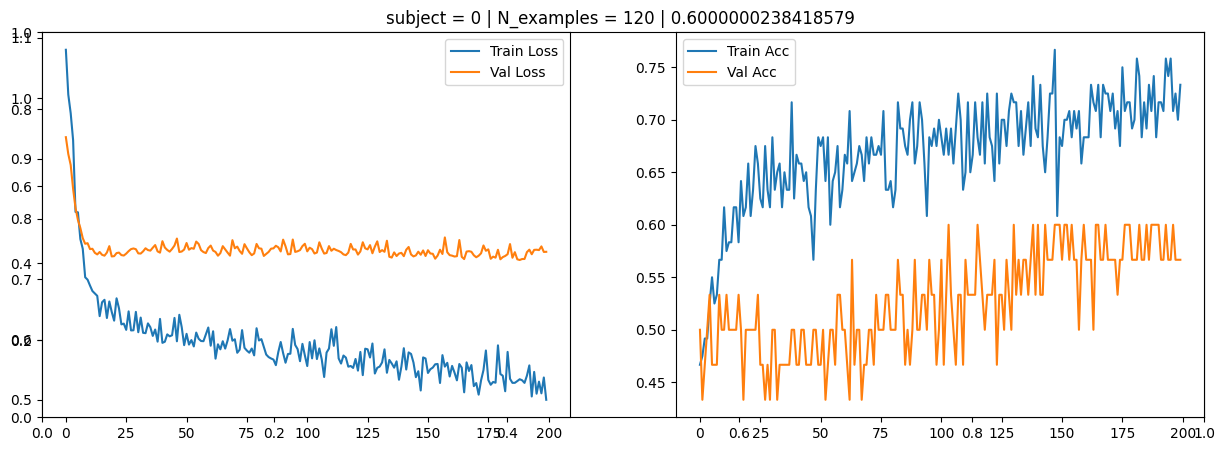

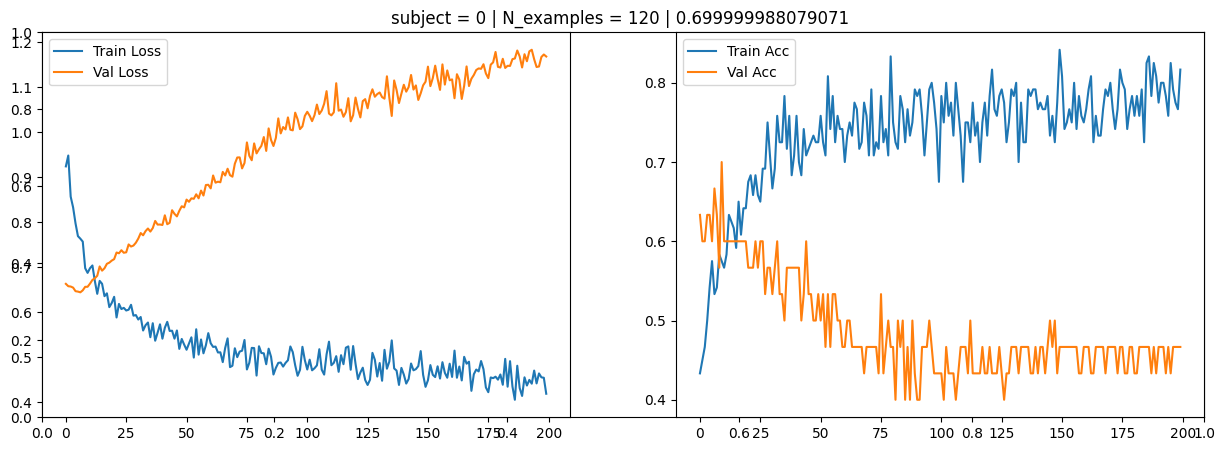

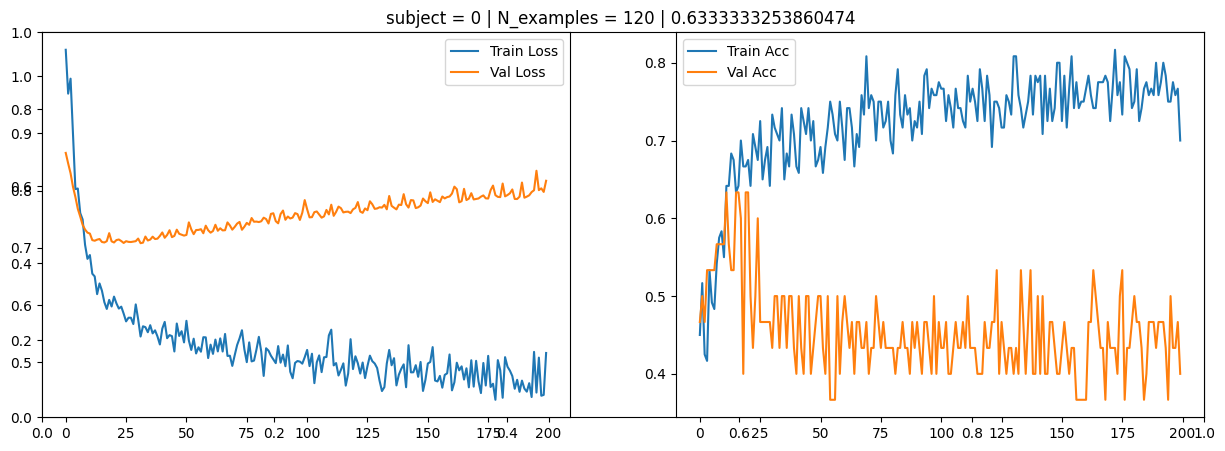

In [6]:
config.stride = 0.2
config.window_size = 2.0





X, y = dataset_NewEEG.session_dataset(config, f'I{config.test_session:02d}')










#crossValidation_KF = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
crossValidation_KF = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=0)


acc = []
Y_preds = []

shuffle_indices = np.random.permutation(len(y))



X = X[shuffle_indices]
y = y[shuffle_indices]

for train_index, valid_index in tqdm.tqdm(crossValidation_KF.split(X,y)):


    model = tf.keras.models.load_model('best_model2D.tf')
    #model.trainable = False 


    for layer in model.layers:
        layer.trainable = False

        if layer.name == 'fc':
            layer.trainable = True





    X_train = X[train_index]
    Y_train = y[train_index]
    X_valid = X[valid_index]
    Y_valid = y[valid_index]
    #print("Training indices: ", train_index)
    #print("Validation indices: ", valid_index)


    # A better alternative is to slice the dataset before for preocessing time efficiency, however since our dataset is extremely small it doesn't matter in this case.
    X_train, Y_train = dataset_NewEEG.slice_EEG_epoch(config, X_train, Y_train)
    X_valid, Y_valid = dataset_NewEEG.slice_EEG_epoch(config, X_valid, Y_valid)


    #mu = X_train.mean()
    #sig = X_train.std()

    #X_train = (X_train - mu)/sig
    #X_valid = (X_valid - mu)/sig



    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')



    csp = CSP(n_components=config.n_csp_components, reg=None, log=None, norm_trace=False, transform_into='csp_space')

    #X_train = csp.transform(X_train)
    X_train = csp.fit_transform(X_train, Y_train)
    X_valid = csp.transform(X_valid)

    sys.stdout.close()
    sys.stdout = old_stdout

    #print(X_train.shape)
    X_train = np.expand_dims(X_train, 3)
    X_valid = np.expand_dims(X_valid, 3)

    #X_train = X_train.transpose(0, 2, 1)
    #X_valid = X_valid.transpose(0, 2, 1)

    Y_train = tf.keras.utils.to_categorical(Y_train, num_classes = len(config.used_classes))
    Y_valid = tf.keras.utils.to_categorical(Y_valid, num_classes = len(config.used_classes))



    #model = NetCNN2D_CSP(len(config.used_classes)) #NetCNN2D_CSP(len(config.used_classes)) 


    model.compile(
            loss= CategoricalCrossentropy(from_logits=True, label_smoothing=0.01),
            optimizer=keras.optimizers.Adam(learning_rate=1e-3, weight_decay = 5e-7), 
            metrics=[keras.metrics.CategoricalAccuracy(name='acc')]
    ) 



    

    history = model.fit(X_train, Y_train, validation_data=(X_valid, Y_valid), epochs=200, batch_size=16, verbose=0)

    
    plt.figure(figsize=(15,5))
    plt.title(f"subject = {0} | N_examples = {X_train.shape[0]} | {max(history.history['val_acc'])} ")

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.legend(["Train Loss", "Val Loss"])

    plt.subplot(1,2,2)
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
    plt.legend(["Train Acc", "Val Acc"])

    acc.append(max(history.history['val_acc']))
    print(acc[-1])
    

print("\n\n ================================== \n")
print(f"{100*np.mean(acc):.2f}% +- {100*np.std(acc):.1f}")


